# 🍓 草莓監測模型評估與特徵熱點圖 (Grad-CAM) 視覺化工具
本 Jupyter Notebook 專為**草莓成熟度監測自走車專案**設計。本工具旨在提供學術級的模型評估圖表，以利於畢業專題論文與簡報展示。

---

## 🎯 核心功能
1. **📊 混淆矩陣 (Confusion Matrix) 繪製**：透過驗證資料集（`valid`）評估 YOLO 模型在各個成熟度級別上的分類精確度，並利用 `seaborn` 與 `matplotlib` 進行高度客製化的視覺化呈現。
2. **🔥 Grad-CAM (特徵熱點圖) 視覺化**：採用 PyTorch Hook 機制，對 YOLOv11 的特徵融合層（例如 Layer 22 的 `C3k2`）進行梯度與特徵圖提取，直觀展示模型在判斷「第一級 (level_1)」、「第二級 (level_2)」與「第三級 (level_3)」草莓時，視覺特徵的關注焦點。

---

## 🛠️ 技術限制與規範
- **執行環境**：強制綁定 Anaconda `pytorch` 虛擬環境。
- **硬體加速**：優先使用 `cuda:0` (RTX 4060 Ti 16G)。
- **解析度**：依據模型規格，輸入影像預設縮放至 `800x800`。


In [23]:
# ==============================================================================
# 1. 初始化與環境健檢
# ==============================================================================
import sys
# 隔離 Jupyter Kernel 的內部參數干擾，確保環境純淨 (符合 GEMINI.md 規範)
sys.argv = [sys.argv[0]]

import os
import cv2
import glob
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 設定 Matplotlib 中文字型，防止 Windows 系統下中文顯示為亂碼(方塊)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                 # 正常顯示負號

# 檢查 GPU 加速狀態
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🍓 目前執行設備: {device}")
if torch.cuda.is_available():
    print(f"🚀 GPU 設備名稱: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ 未檢測到 GPU，將使用 CPU 進行運算（速度可能較慢）")


🍓 目前執行設備: cuda
🚀 GPU 設備名稱: NVIDIA GeForce RTX 4060 Ti


## 📊 二、混淆矩陣 (Confusion Matrix) 的繪製與解析
混淆矩陣是評估多分類目標檢測模型極為關鍵的指標。在目標檢測任務中，混淆矩陣不僅包含各個類別之間的誤判，更引入了 **Background (背景)** 類別：
- **Background (FP - 虛警)**：模型將背景區域（如葉子、土壤、地膜）錯誤預測為草莓。
- **Background (FN - 漏檢)**：模型未能檢測出真實存在的草莓。

我們將使用 `model.val()` 獲取驗證集上的預測結果，並提取混淆矩陣矩陣，最後使用 `seaborn` 繪製出學術級的熱力圖。


In [24]:
# ==============================================================================
# 2. 執行驗證並提取混淆矩陣
# ==============================================================================
print("⏳ 正在對驗證集進行評估（可能需要數十秒，請稍候）...")

# 載入模型 (請確認此路徑存在)
MODEL_PATH = "runs/detect/exp1a_yolo11s_baseline/weights/best.pt"
DATA_YAML = "strawberry-maturity-yolo-graduate-1/data.yaml"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ 找不到模型檔：{MODEL_PATH}，請確認訓練路徑是否正確。")

model = YOLO(MODEL_PATH)

# 執行 validation，設定 workers=0 避免 Windows 下的多進程報錯，imgsz=800 與訓練對齊
# 必須將 plots 設為 True，YOLO 內部才會正常計算 Confusion Matrix，否則 cm_data 會全為 0
results = model.val(
    data=DATA_YAML,
    split="val",
    imgsz=800,
    workers=0,
    plots=True  # 啟用繪圖以利計算混淆矩陣
)

# 獲取混淆矩陣物件與數據
cm_obj = results.confusion_matrix
cm_data = cm_obj.matrix  # numpy array, shape (nc + 1, nc + 1)
class_names = list(model.names.values()) # ['level_1', 'level_2', 'level_3']
nc = len(class_names)

# 定義具有中文註解的類別標籤
x_labels = class_names + ['background (漏檢)']
y_labels = class_names + ['background (虛警)']

print("\n✅ 混淆矩陣提取成功！")
print("原始矩陣數據：\n", cm_data)


⏳ 正在對驗證集進行評估（可能需要數十秒，請稍候）...
Ultralytics 8.4.51  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16380MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1060.3356.5 MB/s, size: 49.0 KB)
val: Scanning D:\銘澄專區\畢業專題工作區\strawberry-maturity-yolo-graduate-1\valid\labels.cache... 233 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233  0.0s
val: D:\\\strawberry-maturity-yolo-graduate-1\valid\images\235_jpg.rf.84ddb80df24bc686c3e832527bc91b01.jpg: 1 duplicate labels removed
val: D:\\\strawberry-maturity-yolo-graduate-1\valid\images\455_jpg.rf.06ee53852510aca176d0de28f85dd8df.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.3it/s 3.5s0.2s
                   all        233       1508      0.821      0.805      0.862      0.623
               level_1        159        686      0.835    

In [25]:
# ==============================================================================
# 3. 繪製混淆矩陣 (Matplotlib + Seaborn)
# ==============================================================================
# 計算 Normalized (歸一化) 混淆矩陣（依真實類別，即每一列進行歸一化）
cm_normalized = cm_data.copy().astype(float)
for i in range(nc + 1):
    row_sum = cm_normalized[i].sum()
    if row_sum > 0:
        cm_normalized[i] = cm_normalized[i] / row_sum

# 建立圖表：左側展示 Raw Counts，右側展示 Normalized
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# 3.1 繪製原始計數矩陣 (Raw Counts)
# 先將 cm_data 轉換成 int，避免 seaborn 對 float 在使用 fmt='d' 時報錯 ValueError
cm_data_int = cm_data.astype(int)
sns.heatmap(
    cm_data_int,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=x_labels,
    yticklabels=y_labels,
    ax=axes[0],
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"},
    linewidths=0.5,
    linecolor='gray'
)
axes[0].set_title("草莓成熟度檢測混淆矩陣 (原始計數 Raw Counts)", fontsize=15, pad=15, weight='bold')
axes[0].set_xlabel("真實類別 (Ground Truth)", fontsize=12, labelpad=10)
axes[0].set_ylabel("預測類別 (Predictions)", fontsize=12, labelpad=10)

# 3.2 繪製歸一化矩陣 (Normalized)
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='RdPu',  # 使用美麗的紅紫色調
    xticklabels=x_labels,
    yticklabels=y_labels,
    ax=axes[1],
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"},
    linewidths=0.5,
    linecolor='gray'
)
axes[1].set_title("草莓成熟度檢測混淆矩陣 (歸一化比例 Normalized)", fontsize=15, pad=15, weight='bold')
axes[1].set_xlabel("真實類別 (Ground Truth)", fontsize=12, labelpad=10)
axes[1].set_ylabel("預測類別 (Predictions)", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()


<Figure size 1800x750 with 4 Axes>

## 🔥 三、Grad-CAM (特徵熱點圖) 視覺化
Grad-CAM (Gradient-weighted Class Activation Mapping) 通過計算目標類別分數相對於卷積層特徵圖的梯度，來評估特徵圖中每個像素對該預測結果的貢獻度。

對於 YOLOv11 目標檢測模型，因為 Detect Head 同時輸出類別與邊界框，我們選取指定類別在所有錨框 (Anchors) 上的預測最大分數（或是特定閾值以上的分數加總）作為反向傳播的起點 $y_c$，這能讓特徵熱點高度聚焦在被成功辨識的草莓實體上。

### 選擇目標特徵層 (Target Layer)
YOLOv11 結構由 Backbone、Neck 與 Head 組成。一般而言：
- **Layer 16 (`C3k2`)**：捕捉小目標特徵的融合層。
- **Layer 19 (`C3k2`)**：捕捉中目標特徵的融合層。
- **Layer 22 (`C3k2`)**：捕捉大目標特徵的融合層。
我們預設使用 **Layer 22**，因為它位於 Neck 的尾端，具有最高層級的語意特徵（包含顏色、形狀、成熟度等語意），能生成最清晰的熱點圖。


In [26]:
# ==============================================================================
# 4. Grad-CAM 多尺度與實體級融合核心演算法類別定義
# ==============================================================================
import torch.nn.functional as F

def cxcywh_to_xyxy(bboxes):
    x_c, y_c, w, h = bboxes[0], bboxes[1], bboxes[2], bboxes[3]
    x1 = x_c - w / 2
    y1 = y_c - h / 2
    x2 = x_c + w / 2
    y2 = y_c + h / 2
    return torch.stack([x1, y1, x2, y2], dim=0)

def calculate_iou(box1, box2):
    x1 = torch.max(box1[0], box2[0])
    y1 = torch.max(box1[1], box2[1])
    x2 = torch.min(box1[2], box2[2])
    y2 = torch.min(box1[3], box2[3])
    intersection = torch.clamp(x2 - x1, min=0) * torch.clamp(y2 - y1, min=0)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / torch.clamp(union, min=1e-6)

class YOLOGradCAM:
    """
    專為 YOLOv8/v11 檢測模型設計的多尺度 (Multi-scale) & 實體級 (Instance-level) Grad-CAM 實現
    """
    def __init__(self, model):
        self.model = model
        # YOLOv11s 的 Detect 模組在第 23 層
        self.detect = self.model.model[23]
        
        # 取得三個尺度的類別預測特徵層 (128 channels)
        self.target_layers = [
            self.detect.cv3[0][1], # stride 8 (小目標)
            self.detect.cv3[1][1], # stride 16 (中目標)
            self.detect.cv3[2][1]  # stride 32 (大目標)
        ]
        
        self.activations = [None, None, None]
        self.gradients = [None, None, None]
        self.hooks = []
        
        # 註冊 hooks
        for i, layer in enumerate(self.target_layers):
            self.hooks.append(layer.register_forward_hook(self.make_save_activation(i)))
            self.hooks.append(layer.register_full_backward_hook(self.make_save_gradient(i)))
            
    def make_save_activation(self, idx):
        def save_activation(model, input, output):
            self.activations[idx] = output
        return save_activation
        
    def make_save_gradient(self, idx):
        def save_gradient(model, grad_input, grad_output):
            self.gradients[idx] = grad_output[0]
        return save_gradient
        
    def __call__(self, x, class_idx, instance_bbox=None, conf_threshold=0.25, iou_threshold=0.5):
        """
        計算指定類別的 Grad-CAM
        x: 前處理後的圖像 Tensor, shape [1, 3, H, W]
        class_idx: 目標類別索引 (0: level_1, 1: level_2, 2: level_3)
        instance_bbox: 可選。若指定，則只針對對應檢測框的 anchors 進行反向傳播
        """
        self.model.zero_grad()
        self.gradients = [None, None, None]  # 清空梯度
        
        # 執行 Forward Pass，使用 grad_enabled(True) 確保能求導
        with torch.set_grad_enabled(True):
            outputs = self.model(x)
        preds = outputs[0]  # shape: [1, 7, 13125]
        
        # 提取目標類別的分數
        class_scores = preds[0, 4 + class_idx, :]
        
        if instance_bbox is not None:
            # 實體級模式：計算各個 anchors 與指定 bbox 的 IoU
            anchor_bboxes_xyxy = cxcywh_to_xyxy(preds[0, :4, :])
            target_box_tensor = torch.tensor(instance_bbox, dtype=torch.float32, device=preds.device)
            ious = calculate_iou(anchor_bboxes_xyxy, target_box_tensor)
            
            # 篩選出 IoU >= iou_threshold 且置信度高於門檻的 anchors
            mask = (ious >= iou_threshold) & (class_scores > conf_threshold)
            num_matched = mask.sum().item()
            
            if num_matched > 0:
                score = class_scores[mask].sum()
                score.backward(retain_graph=True)
            else:
                # 備用機制：若無大於門檻的，則取 IoU 最大的那個 anchor 的 score 進行反向傳播，以自癒並防止無梯度
                best_idx = ious.argmax().item()
                score = class_scores[best_idx]
                score.backward(retain_graph=True)
        else:
            # 全局模式
            mask = class_scores > conf_threshold
            if mask.sum() > 0:
                score = class_scores[mask].sum()
                score.backward(retain_graph=True)
            else:
                return None, 0.0
            
        # 融合三個尺度的 CAM
        h_target, w_target = x.shape[2], x.shape[3]
        cam_total = torch.zeros((h_target, w_target), device=x.device)
        
        for i in range(3):
            act = self.activations[i]
            grad = self.gradients[i]
            if grad is not None and act is not None:
                # 對梯度進行全局平均池化 (GAP)
                weights = torch.mean(grad, dim=(2, 3), keepdim=True)
                # 將通道權重與特徵圖加權求和
                cam = torch.sum(weights * act, dim=1, keepdim=True)
                # 應用 ReLU
                cam = torch.clamp(cam, min=0)
                # 雙線性插值放大至原圖尺寸
                cam_resized = F.interpolate(cam, size=(h_target, w_target), mode='bilinear', align_corners=False)
                cam_total += cam_resized[0, 0]
                
        # 歸一化至 0 ~ 1 範圍
        cam_np = cam_total.cpu().detach().numpy()
        if cam_np.max() > 0:
            cam_np = cam_np / cam_np.max()
            
        return cam_np, score.item()
        
    def release(self):
        for hook in self.hooks:
            hook.remove()
        print("🔓 hooks 已成功釋放。")


### 🖼️ 隨機挑選圖片並繪製特徵熱點圖
我們將在驗證集（`valid/images`）中隨機選取一張草莓影像，並將其送入模型中。
該函數將自動生成 4 張並排的影像：
1. **原圖**：顯示原始採集的影像。
2. **第一級 (level_1) 熱力圖**：顯示模型判斷「第一級成熟度（未成熟/青綠色）」的特徵關注區域。
3. **第二級 (level_2) 熱力圖**：顯示模型判斷「第二級成熟度（半熟/粉紅色）」的特徵關注區域。
4. **第三級 (level_3) 熱力圖**：顯示模型判斷「第三級成熟度（完全成熟/鮮紅色）」的特徵關注區域。


In [27]:
# ==============================================================================
# 5. Grad-CAM 視覺化整合繪圖函數
# ==============================================================================
def run_gradcam_visualization(image_path=None, target_instance_idx=None, conf_threshold=0.25, iou_threshold=0.5):
    if image_path is None:
        valid_images = glob.glob("strawberry-maturity-yolo-graduate-1/valid/images/*.jpg")
        if not valid_images:
            print("❌ 找不到 valid/images 目錄或裡面沒有 JPG 圖片！")
            return
        image_path = random.choice(valid_images)
        
    print(f"📸 處理影像路徑: {image_path}")
    
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ 無法讀取影像: {image_path}")
        return
        
    h_org, w_org, _ = img_bgr.shape
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    img_resized = cv2.resize(img_rgb, (800, 800))
    x_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    x_tensor = x_tensor.unsqueeze(0).to(device)
    x_tensor.requires_grad = True
    
    # 5.3 載入兩個獨立 YOLO 模型實例，避免 predict 的 inference_mode 標記權重為 Inference Tensor
    detector = YOLO(MODEL_PATH)
    results = detector.predict(image_path, conf=conf_threshold, imgsz=800, verbose=False)[0]
    
    temp_model = YOLO(MODEL_PATH)
    py_model = temp_model.model.to(device)
    py_model.eval()
    
    # 5.4 建立 Grad-CAM 實例
    grad_cam = YOLOGradCAM(py_model)
    
    classes_zh = ['第一級 level_1 (未成熟/青綠色)', 
                  '第二級 level_2 (半熟/粉紅色)', 
                  '第三級 level_3 (完全成熟/鮮紅色)']
                  
    # 5.5 判斷模式與繪圖排版
    if target_instance_idx is not None:
        if len(results.boxes) == 0:
            print("⚠️ 影像中沒有偵測到任何目標，自動切換至全圖模式。")
            target_instance_idx = None
        elif target_instance_idx >= len(results.boxes):
            print(f"⚠️ 指定實體索引 [{target_instance_idx}] 溢位，自動切換至實體 [0]。")
            target_instance_idx = 0
            
    if target_instance_idx is not None:
        # 實體級模式繪圖 (2x2 排版)
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        axes = axes.ravel()
        
        box = results.boxes[target_instance_idx]
        cls_idx = int(box.cls.item())
        xyxy = box.xyxy[0].cpu().numpy()
        
        # 1. 繪製原圖加框
        img_annotate = img_rgb.copy()
        for j, b in enumerate(results.boxes):
            b_xyxy = b.xyxy[0].cpu().numpy().astype(int)
            b_cls = int(b.cls.item())
            b_conf = b.conf.item()
            color = (0, 255, 0) if j == target_instance_idx else (255, 0, 0)
            thickness = 3 if j == target_instance_idx else 1
            cv2.rectangle(img_annotate, (b_xyxy[0], b_xyxy[1]), (b_xyxy[2], b_xyxy[3]), color, thickness)
            cv2.putText(img_annotate, f'[{j}] L{b_cls+1} {b_conf:.2f}', (b_xyxy[0], b_xyxy[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
                        
        axes[0].imshow(img_annotate)
        axes[0].set_title(f'原始影像 (標註偵測目標，綠色 [{target_instance_idx}] 為被解釋個體)', fontsize=12, weight='bold')
        axes[0].axis('off')
        
        # 2. 計算實體級 Grad-CAM
        xyxy_800 = [
            xyxy[0] * 800.0 / w_org,
            xyxy[1] * 800.0 / h_org,
            xyxy[2] * 800.0 / w_org,
            xyxy[3] * 800.0 / h_org
        ]
        cam_inst, score_inst = grad_cam(x_tensor, cls_idx, instance_bbox=xyxy_800, conf_threshold=conf_threshold, iou_threshold=iou_threshold)
        if cam_inst is not None:
            cam_inst_resized = cv2.resize(cam_inst, (w_org, h_org))
            heatmap_inst = cv2.applyColorMap(np.uint8(255 * cam_inst_resized), cv2.COLORMAP_JET)
            heatmap_inst = cv2.cvtColor(heatmap_inst, cv2.COLOR_BGR2RGB)
            overlay_inst = cv2.addWeighted(img_rgb, 0.6, heatmap_inst, 0.4, 0)
            cv2.rectangle(overlay_inst, (int(xyxy[0]), int(xyxy[1])), (int(xyxy[2]), int(xyxy[3])), (0, 255, 0), 3)
            axes[1].imshow(overlay_inst)
            axes[1].set_title(f'指定實體 [{target_instance_idx}] ({classes_zh[cls_idx]}) 特徵聚焦 Grad-CAM\n(個體回應強度 Score: {score_inst:.4f})', fontsize=12, weight='bold')
        else:
            axes[1].imshow(img_rgb)
            axes[1].set_title(f'實體 [{target_instance_idx}] Grad-CAM (無回應)', fontsize=12, color='gray')
        axes[1].axis('off')
        
        # 3. 計算全圖同類別對照組
        cam_global, score_global = grad_cam(x_tensor, cls_idx, instance_bbox=None, conf_threshold=conf_threshold)
        if cam_global is not None:
            cam_global_resized = cv2.resize(cam_global, (w_org, h_org))
            heatmap_global = cv2.applyColorMap(np.uint8(255 * cam_global_resized), cv2.COLORMAP_JET)
            heatmap_global = cv2.cvtColor(heatmap_global, cv2.COLOR_BGR2RGB)
            overlay_global = cv2.addWeighted(img_rgb, 0.6, heatmap_global, 0.4, 0)
            cv2.rectangle(overlay_global, (int(xyxy[0]), int(xyxy[1])), (int(xyxy[2]), int(xyxy[3])), (255, 255, 0), 2)
            axes[2].imshow(overlay_global)
            axes[2].set_title(f'全圖同成熟度類別對照 (Global CAM)\n(全圖回應強度 Score: {score_global:.4f})', fontsize=12, weight='bold')
        else:
            axes[2].imshow(img_rgb)
            axes[2].set_title("全圖同成熟度對照 (無回應)", fontsize=12, color='gray')
        axes[2].axis('off')
        
        # 4. 繪製其他非目標成熟度類別的 Global CAM 以利對比
        other_cls = (cls_idx + 1) % 3
        cam_other, score_other = grad_cam(x_tensor, other_cls, instance_bbox=None, conf_threshold=conf_threshold)
        if cam_other is not None:
            cam_other_resized = cv2.resize(cam_other, (w_org, h_org))
            heatmap_other = cv2.applyColorMap(np.uint8(255 * cam_other_resized), cv2.COLORMAP_JET)
            heatmap_other = cv2.cvtColor(heatmap_other, cv2.COLOR_BGR2RGB)
            overlay_other = cv2.addWeighted(img_rgb, 0.6, heatmap_other, 0.4, 0)
            axes[3].imshow(overlay_other)
            axes[3].set_title(f'其他成熟度類別對照: {classes_zh[other_cls]}\n(全圖回應強度 Score: {score_other:.4f})', fontsize=12, weight='bold')
        else:
            gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
            gray_img_3ch = cv2.merge([gray_img, gray_img, gray_img])
            faded = cv2.addWeighted(img_rgb, 0.3, gray_img_3ch, 0.7, 0)
            axes[3].imshow(faded)
            axes[3].set_title(f'其他成熟度對照: {classes_zh[other_cls]} (無偵測目標)', fontsize=12, color='gray')
            axes[3].text(w_org // 2, h_org // 2, '此成熟度級別未檢測到目標', color='yellow', fontsize=12, weight='bold',
                         horizontalalignment='center', verticalalignment='center',
                         bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.4'))
        axes[3].axis('off')
        
        save_mode_str = f'instance{target_instance_idx}'
    else:
        # 全局模式繪圖
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        axes = axes.ravel()
        
        axes[0].imshow(img_rgb)
        axes[0].set_title(f'原始影像 ({os.path.basename(image_path)})', fontsize=12, weight='bold')
        axes[0].axis('off')
        
        for i, cls_name in enumerate(classes_zh):
            cam, score = grad_cam(x_tensor, i, conf_threshold=conf_threshold)
            if cam is not None:
                cam_resized = cv2.resize(cam, (w_org, h_org))
                heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
                heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
                overlay = cv2.addWeighted(img_rgb, 0.6, heatmap, 0.4, 0)
                axes[i+1].imshow(overlay)
                axes[i+1].set_title(f'{cls_name}\n(模型回應強度 Score: {score:.4f})', fontsize=12, pad=10, weight='bold')
            else:
                gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
                gray_img_3ch = cv2.merge([gray_img, gray_img, gray_img])
                faded = cv2.addWeighted(img_rgb, 0.3, gray_img_3ch, 0.7, 0)
                axes[i+1].imshow(faded)
                axes[i+1].set_title(f'{cls_name}\n(無檢測到此成熟度目標)', fontsize=12, pad=10, color='gray', style='italic')
                axes[i+1].text(w_org // 2, h_org // 2, '此成熟度級別未檢測到目標', 
                               color='yellow', fontsize=14, weight='bold', 
                               horizontalalignment='center', verticalalignment='center',
                               bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.5'))
            axes[i+1].axis('off')
            
        save_mode_str = 'global'
        
    plt.tight_layout()
    
    # --- create model-named subfolder ---
    model_dir_name = os.path.basename(os.path.dirname(os.path.dirname(MODEL_PATH)))
    save_dir = os.path.join('evaluation_results', model_dir_name)
    os.makedirs(save_dir, exist_ok=True)
    img_basename = os.path.splitext(os.path.basename(image_path))[0]
    conf_tag = f'conf{int(conf_threshold*100):02d}'
    iou_tag  = f'iou{int(iou_threshold*100):02d}'
    save_path = os.path.join(save_dir, f'gradcam_{model_dir_name}_{img_basename}_{save_mode_str}_{conf_tag}_{iou_tag}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"💾 Grad-CAM 特徵圖已成功儲存至: {save_path}")
    plt.show()
    
    grad_cam.release()


In [28]:
# ==============================================================================
# 6. 批次執行視覺化 (自動生成全圖與單一實體對照的 Grad-CAM 成果圖並保存)
# ==============================================================================
import random
valid_images = glob.glob("strawberry-maturity-yolo-graduate-1/valid/images/*.jpg")
if valid_images:
    print("⏳ 正在對驗證集進行篩選，以獲取適合論文插圖的影像...")
    detector = YOLO(MODEL_PATH)
    multi_strawberries_imgs = []
    single_strawberry_imgs = []
    
    random.shuffle(valid_images)
    for img_path in valid_images:
        res = detector.predict(img_path, conf=0.25, verbose=False)[0]
        if len(res.boxes) >= 2:
            multi_strawberries_imgs.append(img_path)
            if len(multi_strawberries_imgs) >= 5:
                break
        elif len(res.boxes) == 1:
            single_strawberry_imgs.append(img_path)
            
    selected_imgs = multi_strawberries_imgs[:5]
    needed = 10 - len(selected_imgs)
    selected_imgs.extend(single_strawberry_imgs[:needed])
    if len(selected_imgs) < 10:
        remaining = [img for img in valid_images if img not in selected_imgs]
        selected_imgs.extend(remaining[:10 - len(selected_imgs)])
        
    print(f"🚀 開始批次生成並保存 {len(selected_imgs)} 張影像的多尺度/實體級 Grad-CAM 特徵圖...")
    for i, img_path in enumerate(selected_imgs):
        if i < 5:
            run_gradcam_visualization(image_path=img_path, target_instance_idx=0, conf_threshold=0.25)
        else:
            run_gradcam_visualization(image_path=img_path, target_instance_idx=None, conf_threshold=0.25)
    print("\n🎉 批次生成完成！所有結果已保存在 evaluation_results/ 資料夾中，可用於論文挑選。")
else:
    print("❌ 找不到 valid/images 目錄或裡面沒有 JPG 圖片！")


⏳ 正在對驗證集進行篩選，以獲取適合論文插圖的影像...
🚀 開始批次生成並保存 10 張影像的多尺度/實體級 Grad-CAM 特徵圖...
📸 處理影像路徑: strawberry-maturity-yolo-graduate-1/valid/images\692_jpg.rf.fd23fa240437cf23ae7ed293accfa8a6.jpg
💾 Grad-CAM 特徵圖已成功儲存至: evaluation_results\gradcam_exp1a_yolo11s_baseline_692_jpg.rf.fd23fa240437cf23ae7ed293accfa8a6_instance0.png


<Figure size 1400x1200 with 4 Axes>

🔓 hooks 已成功釋放。
📸 處理影像路徑: strawberry-maturity-yolo-graduate-1/valid/images\4_jpg.rf.2a6eb4f9cc770008cb5966c80b651987.jpg
💾 Grad-CAM 特徵圖已成功儲存至: evaluation_results\gradcam_exp1a_yolo11s_baseline_4_jpg.rf.2a6eb4f9cc770008cb5966c80b651987_instance0.png


<Figure size 1400x1200 with 4 Axes>

🔓 hooks 已成功釋放。
📸 處理影像路徑: strawberry-maturity-yolo-graduate-1/valid/images\465_jpg.rf.b8e2959b4d1e6e90a4031cd318c99a03.jpg
💾 Grad-CAM 特徵圖已成功儲存至: evaluation_results\gradcam_exp1a_yolo11s_baseline_465_jpg.rf.b8e2959b4d1e6e90a4031cd318c99a03_instance0.png


...

🔓 hooks 已成功釋放。
📸 處理影像路徑: strawberry-maturity-yolo-graduate-1/valid/images\295_jpg.rf.81adebaade5f56816e8582902d860a49.jpg
💾 Grad-CAM 特徵圖已成功儲存至: evaluation_results\gradcam_exp1a_yolo11s_baseline_295_jpg.rf.81adebaade5f56816e8582902d860a49_global.png


<Figure size 1400x1200 with 4 Axes>

🔓 hooks 已成功釋放。
📸 處理影像路徑: strawberry-maturity-yolo-graduate-1/valid/images\291_jpg.rf.57216997a8c1f3e2bf5357c343fc2200.jpg
💾 Grad-CAM 特徵圖已成功儲存至: evaluation_results\gradcam_exp1a_yolo11s_baseline_291_jpg.rf.57216997a8c1f3e2bf5357c343fc2200_global.png


<Figure size 1400x1200 with 4 Axes>

🔓 hooks 已成功釋放。

🎉 批次生成完成！所有結果已保存在 evaluation_results/ 資料夾中，可用於論文挑選。


📸 處理影像路徑: strawberry-maturity-yolo-graduate-1\valid\images\1008_jpg.rf.2ebf5cb716779583008f6f72d36a633c.jpg
💾 Grad-CAM 特徵圖已成功儲存至: evaluation_results\exp1a_yolo11s_baseline\gradcam_exp1a_yolo11s_baseline_1008_global_conf10_iou30.png


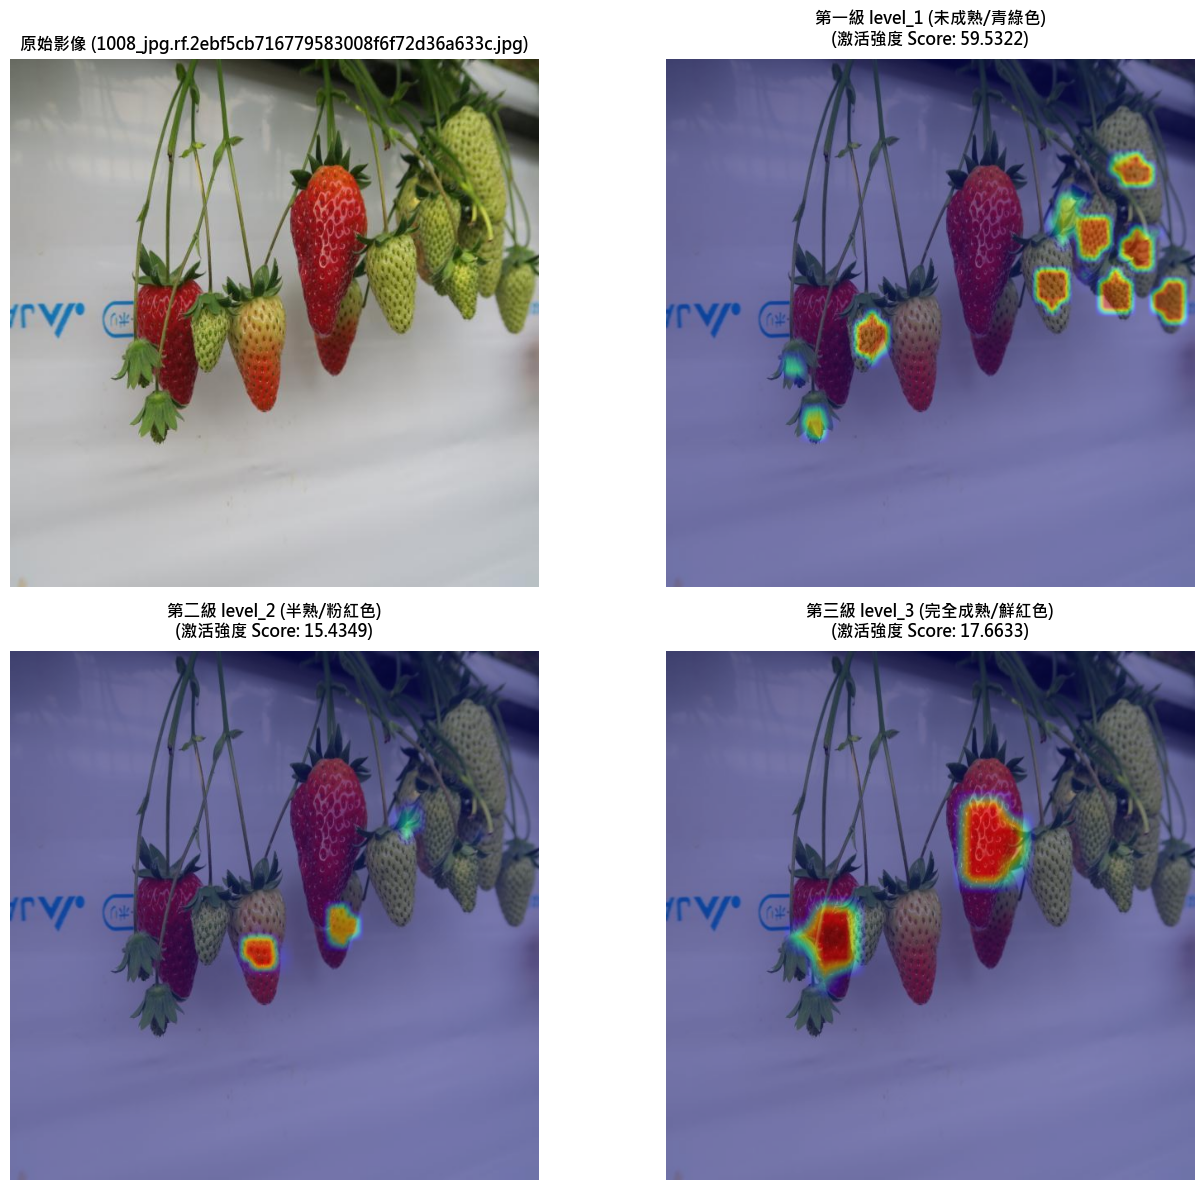

🔓 hooks 已成功釋放。


In [3]:
# ==============================================================================
# 🎯 自訂單張影像 Grad-CAM 視覺化與分析（參數調整測試用）
# 本 Cell 可單獨執行，無需先執行前面的 Cell。
# ==============================================================================
import sys, os

# --- 自動將 agent_tools 加入模組搜尋路徑 ---
if 'agent_tools' not in sys.path[0]:
    sys.path.insert(0, os.getcwd())

from agent_tools.gradcam_utils import run_gradcam_visualization

# 若前面 Cell 沒跑，自動補齊 MODEL_PATH
try:
    MODEL_PATH
except NameError:
    MODEL_PATH = "runs/detect/exp1a_yolo11s_baseline/weights/best.pt"

import agent_tools.gradcam_utils as _gu
_gu.MODEL_PATH = MODEL_PATH

# ──────────────────────────────────────────────
# 1. 填寫您想測試的草莓影像路徑
#    加上 r 後，反斜線不會被轉義
CUSTOM_IMG_PATH = r"strawberry-maturity-yolo-graduate-1\valid\images\1008_jpg.rf.2ebf5cb716779583008f6f72d36a633c.jpg"

# 2. 設定解釋模式
#    - 數字 (如 0, 1, 2)：單一實體級 Grad-CAM，聚焦在指定編號的草莓
#    - None             ：全圖模式，展示三種成熟度的特徵分佈
TARGET_INSTANCE = None

# 3. 執行視覺化（可自訂 conf / iou 門檻）
#    輸出路徑：evaluation_results/<模型名>/<檔名>_<模式>_conf<n>_iou<n>.png
if os.path.exists(CUSTOM_IMG_PATH):
    run_gradcam_visualization(
        image_path=CUSTOM_IMG_PATH,
        target_instance_idx=TARGET_INSTANCE,
        conf_threshold=0.1,
        iou_threshold=0.3,
    )
else:
    print(f"❌ 找不到指定的影像檔案，請確認路徑是否正確：{CUSTOM_IMG_PATH}")
